# llama3.1:8b — evaluation

Text-block classification into five classes, evaluated against a manually annotated
reference set of 10 Data Management Plans. PDF text extracted with pdfplumber.


In [1]:
import os
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

import numpy as np
import matplotlib.pyplot as plt

from dmpbridge.evaluation.evaluate import (
    load_method as load_method_old, micro_prf1, compute_f1_rows, LABELS,
)

MODEL, TAG = 'llama3.1:8b', 'llama3.1-8b_pdfplumber_whole_doc'

df, conf, errors = load_method_old(TAG, exclude=[])
print(f'{MODEL}: {len(df)} documents')


llama3.1:8b: 10 documents


## 1. Metrics

Each predicted block is matched to a reference block by token overlap. A matched pair
with the same class is a **true positive (TP)**. A prediction with the wrong class, or
with no reference counterpart, is a **false positive (FP)**. A reference block that the
prediction failed to match, or matched with the wrong class, is a **false negative (FN)**.

$$\\text{precision} = \\frac{TP}{TP + FP} \\qquad
\\text{recall} = \\frac{TP}{TP + FN} \\qquad
F_1 = 2 \\cdot \\frac{\\text{precision} \\cdot \\text{recall}}
{\\text{precision} + \\text{recall}}$$

Precision falls when the model over-generates; recall falls when it under-generates.
$F_1$ is their harmonic mean and is low unless both are high.

A **confusion matrix** cross-tabulates the true class against the predicted class, so
the diagonal counts agreements and off-diagonal cells identify which classes are being
substituted for which. It is reported in section 3.

Scores below are **micro-averaged**: computed over the pooled counts, so every block
contributes equally regardless of class frequency.


In [2]:
m = micro_prf1(conf)

print(f'{MODEL} — micro-averaged over 10 documents')
print()
print(f"  TP  {m['tp']:>4}")
print(f"  FP  {m['fp']:>4}")
print(f"  FN  {m['fn']:>4}")
print()
print(f"  precision  {m['precision']:.3f}")
print(f"  recall     {m['recall']:.3f}")
print(f"  f1-score   {m['f1']:.3f}")


llama3.1:8b — micro-averaged over 10 documents

  TP    96
  FP    82
  FN    36

  precision  0.539
  recall     0.727
  f1-score   0.619


## 2. Classification report

Precision, recall and $F_1$ per class, with support (the number of reference blocks of
that class). Reported in the conventional layout.


In [3]:
per_class = compute_f1_rows(conf).set_index('label')

print(f"{'':<22}{'precision':>10}{'recall':>9}{'f1-score':>10}{'support':>9}")
print()
for lab, r in per_class.iterrows():
    print(f"{lab:<22}{r['precision']:>10.3f}{r['recall']:>9.3f}"
          f"{r['f1']:>10.3f}{int(r['support']):>9}")
print()
print(f"{'micro avg':<22}{m['precision']:>10.3f}{m['recall']:>9.3f}"
      f"{m['f1']:>10.3f}{int(per_class['support'].sum()):>9}")
print(f"{'macro avg':<22}{per_class['precision'].mean():>10.3f}"
      f"{per_class['recall'].mean():>9.3f}{per_class['f1'].mean():>10.3f}"
      f"{int(per_class['support'].sum()):>9}")
w = per_class['support'] / per_class['support'].sum()
print(f"{'weighted avg':<22}{(per_class['precision'] * w).sum():>10.3f}"
      f"{(per_class['recall'] * w).sum():>9.3f}{(per_class['f1'] * w).sum():>10.3f}"
      f"{int(per_class['support'].sum()):>9}")


                       precision   recall  f1-score  support

title                      0.900    0.900     0.900       10
section.title              0.593    0.814     0.686       43
section.description        0.750    0.750     0.750        8
question.text              0.031    0.062     0.042       16
answer.text                0.652    0.818     0.726       55

micro avg                  0.539    0.727     0.619      132
macro avg                  0.585    0.669     0.621      132
weighted avg               0.582    0.727     0.645      132


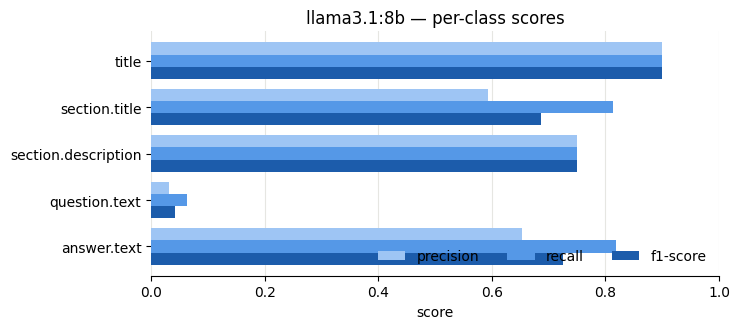

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))
y = np.arange(len(per_class))
h = 0.26
for k, (col, colour) in enumerate((('precision', '#9ec5f4'),
                                   ('recall', '#5598e7'),
                                   ('f1', '#1c5cab'))):
    ax.barh(y + (k - 1) * h, per_class[col], height=h,
            color=colour, label=col if col != 'f1' else 'f1-score')
ax.set_yticks(y)
ax.set_yticklabels(per_class.index)
ax.set_xlim(0, 1)
ax.set_xlabel('score')
ax.invert_yaxis()
ax.legend(frameon=False, ncol=3, loc='lower right')
ax.set_title(f'{MODEL} — per-class scores')
ax.grid(axis='x', color='#e6e6e2', linewidth=0.8)
ax.set_axisbelow(True)
for side in ('top', 'right', 'left'):
    ax.spines[side].set_visible(False)
plt.tight_layout()
plt.show()


## 3. Confusion matrix

Rows are the true class, columns the predicted class. Cell $(i, j)$ counts reference
blocks of class $i$ that were predicted as class $j$; the diagonal counts correct
classifications.

Blocks with no counterpart on either side cannot appear in the matrix — a prediction
with no matching reference block has no true class, and a reference block the model
did not produce has no predicted class. Those are counted separately beneath.


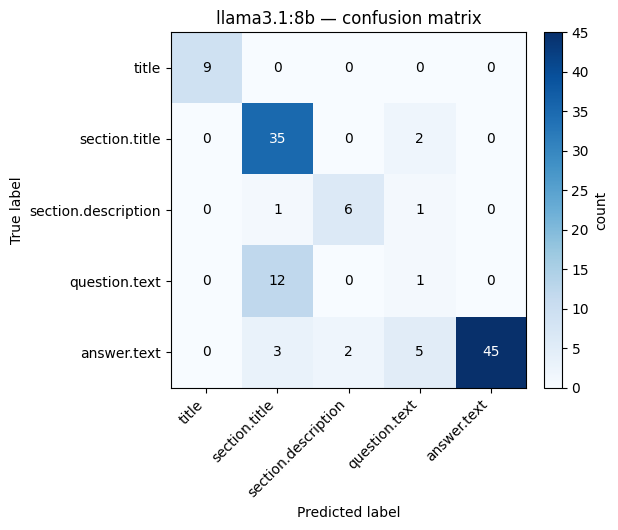

Not representable in the matrix:
  predictions with no matching reference block     56   (count as FP)
  reference blocks with no matching prediction     10   (count as FN)


In [5]:
cm = np.zeros((len(LABELS), len(LABELS)), dtype=int)
for i, true in enumerate(LABELS):
    for j, pred in enumerate(LABELS):
        cm[i, j] = conf.get(true, {}).get(pred, 0)

fig, ax = plt.subplots(figsize=(6.4, 5.4))
im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=cm.max())
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='count')

thresh = cm.max() / 2
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black')

ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(LABELS, rotation=45, ha='right')
ax.set_yticks(range(len(LABELS)))
ax.set_yticklabels(LABELS)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title(f'{MODEL} — confusion matrix')
plt.tight_layout()
plt.show()

unmatched_pred = sum(conf.get('__no_gold__', {}).values())
unmatched_true = sum(conf.get(l, {}).get('__missed__', 0) for l in LABELS)
print(f'Not representable in the matrix:')
print(f'  predictions with no matching reference block   {unmatched_pred:>4}   (count as FP)')
print(f'  reference blocks with no matching prediction   {unmatched_true:>4}   (count as FN)')
